# 01 · Data Understanding & Cleaning

**Retail Customer-Intelligence Platform — Phase 1**

This notebook makes the data-cleaning process *visible*. Working from the raw
**UCI Online Retail II** workbook (a public proxy for the Retailer transaction data),
we answer two questions before touching a model:

1. **Which columns do we need?**
2. **Which rows do we need?** (and how do we treat missing / invalid values)

Business mapping: `StockCode → product/SKU`, `Invoice → basket`,
`Customer ID → Clubcard member`.

Every step below calls the shared functions in `src/data/clean.py`, so this
narrated process is *identical* to the production cleaning used downstream.

In [1]:
import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Make the repo root importable whether this runs from notebooks/ or the root.
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

from src.data import profiling  # noqa: E402
from src.data.clean import CLEANING_STEPS, clean_transactions, load_raw  # noqa: E402

# Keep step INFO logs quiet here — we narrate with explicit tables instead.
logging.getLogger("src.data.clean").setLevel(logging.WARNING)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Load the raw data

The workbook has two sheets (`Year 2009-2010`, `Year 2010-2011`) with identical
columns; we concatenate them and rename to snake_case on load
(`Invoice → invoice`, `StockCode → stock_code`, `Customer ID → customer_id`, …).

In [2]:
raw = load_raw()
print(f"Raw shape: {raw.shape[0]:,} rows × {raw.shape[1]} columns")
raw.head()

Raw shape: 1,067,371 rows × 8 columns


,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
profiling.overview(raw)

rows              1067371.0
columns                 8.0
memory_MB             261.2
duplicate_rows      34335.0
dtype: float64

## 2. Which columns do we need?

A per-column profile (dtype, missingness, distinct values, examples), then a
documented keep/drop verdict. **Conclusion: all eight columns are useful** —
each maps to at least one analysis — so cleaning removes *rows*, not columns.

In [4]:
profiling.column_profile(raw)

,column,dtype,n_missing,pct_missing,n_unique,examples
0,invoice,object,0,0.00,53628,"489434, 489435, 489436"
1,stock_code,object,0,0.00,5305,"85048, 79323P, 79323W"
2,description,object,4382,0.41,5698,"15CM CHRISTMAS GLASS BALL 20 LIGHTS, PINK CHER..."
3,quantity,int64,0,0.00,1057,"12, 48, 24"
4,invoice_date,datetime64[ns],0,0.00,47635,"2009-12-01 07:45:00, 2009-12-01 07:46:00, 2009..."
5,price,float64,0,0.00,2807,"6.95, 6.75, 2.1"
6,customer_id,float64,243007,22.77,5942,"13085.0, 13078.0, 15362.0"
7,country,object,0,0.00,43,"United Kingdom, France, USA"


In [5]:
profiling.column_relevance()

,column,verdict,used_for,note
0,Invoice,Keep,"Basket analysis, de-dup, cancellation flag",Basket key. Leading 'C' marks a cancellation -...
1,StockCode,Keep,"Forecasting, basket, product master","Product key. Non-SKU service codes (POST, DOT,..."
2,Description,Keep,"Human-readable product label, product master",Has some missing values; filled from the modal...
3,Quantity,Keep,"Revenue, demand forecasting, inventory",Non-positive values (returns/adjustments) drop...
4,InvoiceDate,Keep,"Forecasting, recency, seasonality, date dim",Parsed to datetime; spans 2009-12 to 2011-12.
5,Price,Keep,"Revenue, gross-margin model",Unit price (GBP). Non-positive values dropped.
6,Customer ID,Keep,"Segmentation, CLV, churn (member-level)",Missing for guest baskets; required only for m...
7,Country,Keep,"Geography, segmentation, country dim",Low cardinality; UK dominates.


## 3. Missing values

`customer_id` is missing on ~23% of lines — these are **guest / unidentified
baskets**, not an error. We keep them for sales/forecasting/basket analysis and
require an id only for member-level work (segmentation, CLV, churn).
`description` has a tiny amount missing, later filled from the modal description
per SKU.

In [6]:
profiling.missingness(raw)

,n_missing,pct_missing
customer_id,243007,22.77
description,4382,0.41
stock_code,0,0.00
invoice,0,0.00
quantity,0,0.00
invoice_date,0,0.00
price,0,0.00
country,0,0.00


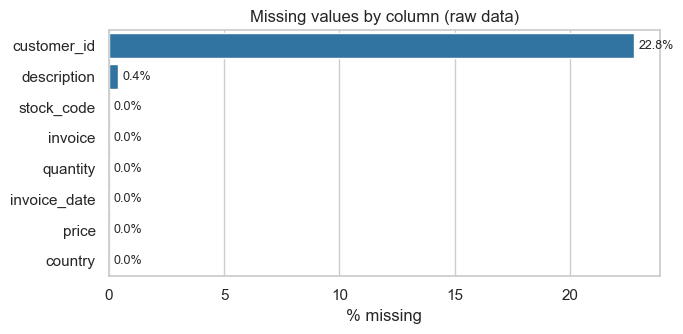

In [7]:
miss = profiling.missingness(raw)
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.barplot(x=miss["pct_missing"], y=miss.index, color="#1f77b4", ax=ax)
ax.set(xlabel="% missing", ylabel="", title="Missing values by column (raw data)")
for y, v in enumerate(miss["pct_missing"]):
    ax.text(v + 0.2, y, f"{v:.1f}%", va="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_missingness.png", dpi=120)
plt.show()

## 4. Which rows do we need? — cleaning, step by step

We apply each cleaning step in order and audit how many rows it removes. The
steps: standardise dtypes → drop unparseable dates → drop exact duplicates →
drop cancellations (`C`-invoices) → drop non-positive qty/price → flag product
vs service codes → add line revenue. (The dtype/flag/revenue steps transform or
add columns and remove zero rows — shown explicitly for transparency.)

In [8]:
df = raw.copy()
audit = []
for label, step in CLEANING_STEPS:
    before = len(df)
    df = step(df)
    audit.append({
        "step": label,
        "rows_before": before,
        "rows_after": len(df),
        "rows_removed": before - len(df),
        "pct_removed": round(100 * (before - len(df)) / before, 2),
    })
audit_df = pd.DataFrame(audit)
audit_df

,step,rows_before,rows_after,rows_removed,pct_removed
0,standardise dtypes,1067371,1067371,0,0.00
1,drop unparseable dates,1067371,1067371,0,0.00
2,drop duplicate rows,1067371,1033036,34335,3.22
3,drop cancellations,1033036,1013932,19104,1.85
4,drop non-positive qty/price,1013932,1007913,6019,0.59
5,flag product vs service codes,1007913,1007913,0,0.00
6,add line revenue,1007913,1007913,0,0.00


The cleaned frame produced by these steps is exactly `clean_transactions(raw)`:

In [9]:
clean = df.reset_index(drop=True)
assert len(clean) == len(clean_transactions(raw)), "narrated steps must match production"
print(f"Clean shape: {clean.shape[0]:,} rows × {clean.shape[1]} columns")
print(f"Retained {100 * len(clean) / len(raw):.1f}% of raw rows")

Clean shape: 1,007,913 rows × 10 columns
Retained 94.4% of raw rows


## 5. The cleaned dataset — before vs after

In [10]:
pd.concat([profiling.overview(raw).rename("raw"),
           profiling.overview(clean).rename("clean")], axis=1)

,raw,clean
rows,1067371.0,1007913.0
columns,8.0,10.0
memory_MB,261.2,291.3
duplicate_rows,34335.0,0.0


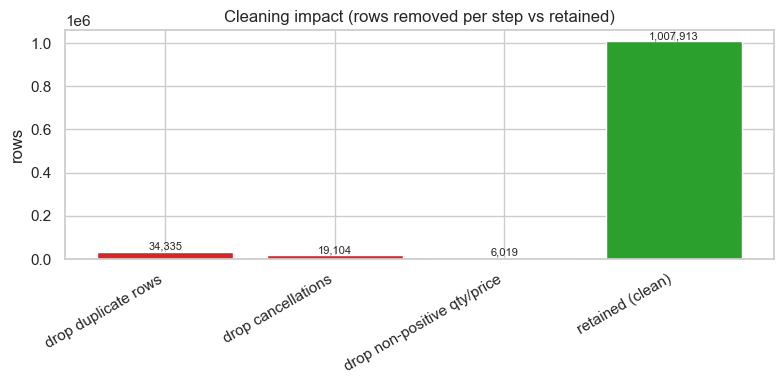

In [11]:
# Cleaning impact: rows removed at each step, then what remains.
removed = audit_df[audit_df["rows_removed"] > 0]
labels = list(removed["step"]) + ["retained (clean)"]
values = list(removed["rows_removed"]) + [len(clean)]
colors = ["#d62728"] * len(removed) + ["#2ca02c"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, values, color=colors)
ax.set(ylabel="rows", title="Cleaning impact (rows removed per step vs retained)")
ax.tick_params(axis="x", rotation=30)
for i, v in enumerate(values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
plt.setp(ax.get_xticklabels(), ha="right")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_cleaning_impact.png", dpi=120)
plt.show()

In [12]:
# Product vs service lines in the clean data, and headline counts.
print("Product vs service lines:")
print(clean["is_product"].value_counts().rename({True: "product", False: "service/admin"}))
print(f"\nDate range : {clean['invoice_date'].min().date()} → {clean['invoice_date'].max().date()}")
print(f"Members    : {clean['customer_id'].nunique():,} (rows with an id)")
print(f"Products   : {clean.loc[clean['is_product'], 'stock_code'].nunique():,}")
print(f"Baskets    : {clean['invoice'].nunique():,}")
clean.head()

Product vs service lines:
is_product
product          1003214
service/admin       4699
Name: count, dtype: int64

Date range : 2009-12-01 → 2011-12-09
Members    : 5,878 (rows with an id)
Products   : 4,877
Baskets    : 40,077


,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,is_product,revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,True,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,True,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,True,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,True,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,True,30.0


## 6. Output & productionization

This exact pipeline lives in `src/data/clean.py` (`clean_transactions`). Running

```bash
python -m src.pipeline.build_features
```

writes the cleaned line-level table to `data/processed/clean_transactions.parquet`
(the input for Phase 2's star-schema warehouse) plus the three feature marts.

**Cleaning decisions (summary):** drop exact duplicates; drop cancellations
(`C`-invoices are returns); drop non-positive quantity/price (adjustments,
freebies); flag non-SKU service codes (POST, DOT, fees) so they don't pollute
product analytics; keep guest baskets (null `customer_id`) for everything except
member-level work. Full column reference: `docs/data_dictionary.md`;
narrative: `docs/cleaning_report.md`.